# LegalBench-RAG Evaluation Plots

Load one or more JSONL trace files (written by `eval_precision_recall.py --trace-file`) and generate individual charts.  

In [9]:
from __future__ import annotations
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    12,
    "axes.labelweight":  "bold",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.shadow":     False,
    "legend.edgecolor":  "0.8",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.4,
    "grid.linestyle":    "--",
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

In [3]:
# ── Color / style maps ────────────────────────────────────────────────────────

# Substring of model label → named color (case-insensitive match)
COLORS: dict[str, str] = {
    "all-mpnet":       "blue",
    "legal-embed-bge": "green",
    "legalbert":       "red",
    "legal-bert":      "red",
    "bert-dpr-clerc":  "purple",
    "clerc":           "purple",
    "octen":           "darkorange",
    "qwen3":           "lightpink",
    "qwen2.5":         "cyan",
    "gemini":          "olive",
}

FALLBACK_COLORS = [
    "blue", "green", "red", "purple",
    "orange", "pink", "brown", "cyan",
    "olive", "gray",
]

MARKERS    = ["o", "s", "^", "D", "v", "*", "P", "X", "h", "p"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3,1,1,1)), (0, (5,2)), "-", "--", "-.", ":"]


def _resolve_color(label: str, used: set[str]) -> str:
    lower = label.lower()
    for key, color in COLORS.items():
        if key in lower and color not in used:
            return color
    for color in FALLBACK_COLORS:
        if color not in used:
            return color
    return FALLBACK_COLORS[len(used) % len(FALLBACK_COLORS)]


def assign_styles(runs: list[dict]) -> None:
    """Attach _style dict to each run in-place."""
    used: set[str] = set()
    for i, run in enumerate(runs):
        color = _resolve_color(run["run_info"]["label"], used)
        used.add(color)
        run["_style"] = {
            "color":     color,
            "marker":    MARKERS[i % len(MARKERS)],
            "linestyle": LINESTYLES[i % len(LINESTYLES)],
        }

In [4]:
# ── Data loading ──────────────────────────────────────────────────────────────

def load_run_summary(path: Path | str) -> dict | None:
    """Read a trace JSONL and return the run_summary record, or None."""
    path = Path(path)
    summary = None
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if rec.get("_type") == "run_summary":
                summary = rec
    if summary is None:
        print(f"WARNING: no run_summary in {path} — skipped")
    return summary


def load_runs(*paths: str | Path) -> list[dict]:
    """Load multiple trace files, assign styles, return run list."""
    runs = [r for p in paths if (r := load_run_summary(p)) is not None]
    assign_styles(runs)
    return runs

In [33]:
# ── Core plot function ────────────────────────────────────────────────────────

def plot_one(
    runs: list[dict],
    metric_key: str,
    *,
    section: str = "overall",          # "overall" or a benchmark name
    title: str | None = None,
    y_label: str | None = None,
    ylim: tuple[float, float] = (0.0, 1.0),
    figsize: tuple[float, float] = (9, 5),
    save_to: str | Path | None = None,
    fmt: str = "png",
) -> None:
    """
    Plot one metric across all runs.

    Parameters
    ----------
    runs       : list returned by load_runs()
    metric_key : one of char_recall_at_k / char_precision_at_k /
                 chunk_recall_at_k / chunk_precision_at_k
    section    : "overall" (default) or a benchmark name like "cuad"
    ylim       : y-axis limits — tune per chart since recall/precision scale differently
    save_to    : file path to save (without extension); if None, just display
    """
    # Collect K values from the first run that has data
    all_ks: list[int] = []
    for run in runs:
        ds = run.get("overall", {}) if section == "overall" else run.get("benchmarks", {}).get(section, {})
        if md := ds.get(metric_key):
            all_ks = sorted(int(k) for k in md)
            break

    fig, ax = plt.subplots(figsize=figsize)

    for run in runs:
        ds = run.get("overall", {}) if section == "overall" else run.get("benchmarks", {}).get(section, {})
        md = ds.get(metric_key, {})
        if not md:
            continue
        ks   = sorted(int(k) for k in md)
        vals = [md[str(k)] for k in ks]
        s    = run["_style"]
        label = run["run_info"]["label"].split("/")[-1]
        ax.plot(ks, vals, label=label,
                color=s["color"], marker=s["marker"],
                linestyle=s["linestyle"], linewidth=2.0, markersize=7)

    max_k = all_ks[-1] if all_ks else 0
    ax.set_xticks(range(0, max_k + 1, 10))
    ax.set_xlim(left=0, right=max_k+5)
    ax.set_ylim(ylim)
    ax.set_xlabel("K (Retrieval Depth)")
    ax.set_ylabel(y_label or metric_key.replace("_at_k", "").replace("_", " ").title())
    ax.set_title(title or f"{metric_key.replace('_at_k', '').replace('_', ' ').title()} — {section}")
    if ax.get_lines():
        ax.legend(loc="best")
    fig.tight_layout()

    if save_to:
        dest = Path(save_to).with_suffix(f".{fmt}")
        dest.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(dest)
        print(f"Saved → {dest}")

    plt.show()

---
## Load runs

In [63]:
EVAL_ROOT = Path("logs/eval")
QUERY_TYPE = ['original', 'gemini_3', 'qwen3.5']

runs = load_runs(
    EVAL_ROOT / QUERY_TYPE[2]/ "lbr_hier_all-mpnet.jsonl",
    EVAL_ROOT / QUERY_TYPE[2]/ "lbr_hier_clerc.jsonl",
    EVAL_ROOT / QUERY_TYPE[2]/ "lbr_hier_legalbert.jsonl",
    EVAL_ROOT / QUERY_TYPE[2]/ "lbr_hier_legal-embed-bge.jsonl",
    EVAL_ROOT / QUERY_TYPE[2]/ "lbr_hier_octen.jsonl",
    EVAL_ROOT / QUERY_TYPE[2]/ "lbr_hier_qwen3.jsonl",
)

print(f"Loaded {len(runs)} runs:")
for r in runs:
    print(" ", r["run_info"]["label"], "  ks:", r["run_info"]["ks"])

Loaded 6 runs:
  sentence-transformers/all-mpnet-base-v2   ks: [2, 4, 6, 10, 15, 20, 40, 60]
  jhu-clsp/BERT-DPR-CLERC-ft   ks: [2, 4, 6, 10, 15, 20, 40, 60]
  nlpaueb/legal-bert-base-uncased   ks: [2, 4, 6, 10, 15, 20, 40, 60]
  axondendriteplus/Legal-Embed-bge-base-en-v1.5   ks: [2, 4, 6, 10, 15, 20, 40, 60]
  Octen/Octen-Embedding-0.6B   ks: [2, 4, 6, 10, 15, 20, 40, 60]
  Qwen/Qwen3-Embedding-0.6B   ks: [2, 4, 6, 10, 15, 20, 40, 60]


---
## Overall — Recall

Saved → logs/eval/qwen3.5/figures/overall_chunk_recall.png


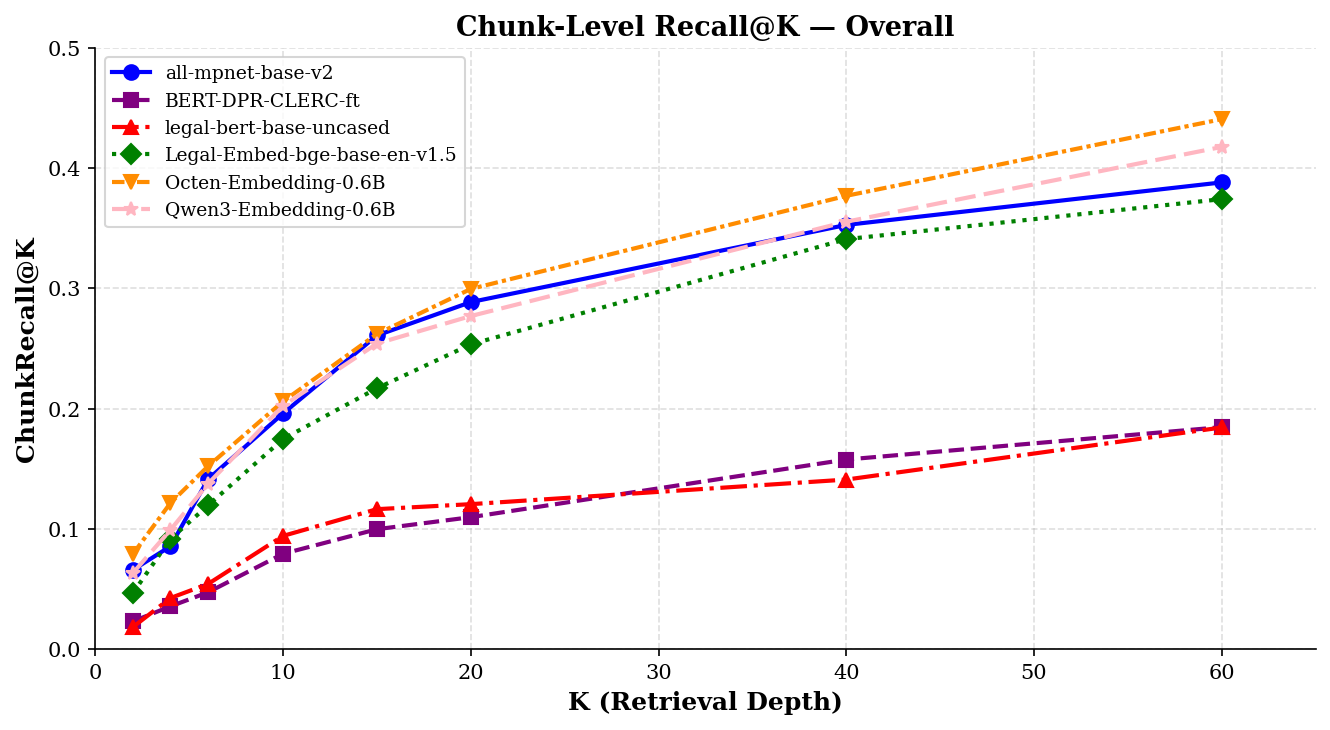

In [64]:
plot_one(
    runs,
    "chunk_recall_at_k",
    section="overall",
    title="Chunk-Level Recall@K — Overall",
    y_label="ChunkRecall@K",
    ylim=(0.0, 0.5),
    save_to= f"{EVAL_ROOT}/{QUERY_TYPE[2]}/figures/overall_chunk_recall",
)

Saved → logs/eval/qwen3.5/figures/overall_char_recall.png


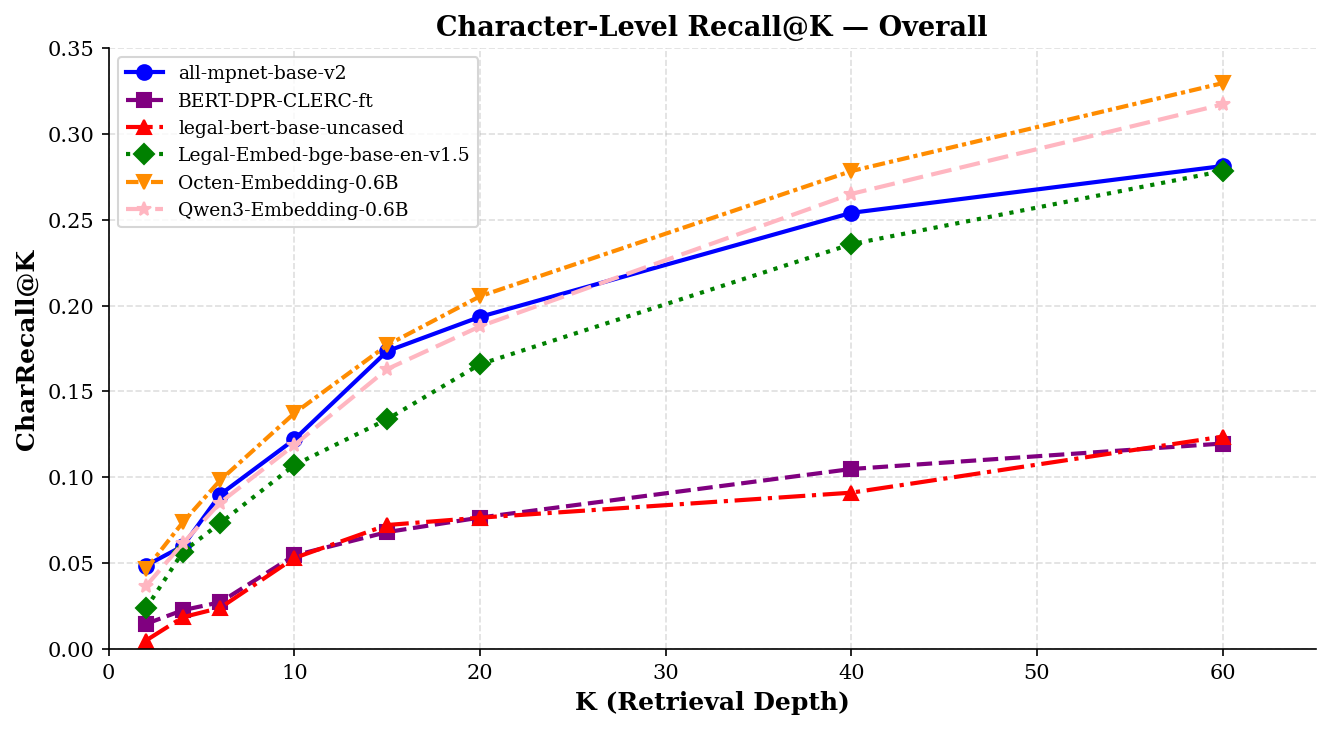

In [65]:
plot_one(
    runs,
    "char_recall_at_k",
    section="overall",
    title="Character-Level Recall@K — Overall",
    y_label="CharRecall@K",
    ylim=(0.0, 0.35),
    save_to=f"{EVAL_ROOT}/{QUERY_TYPE[2]}/figures/overall_char_recall",
)

---
## Overall — Precision

Saved → logs/eval/qwen3.5/figures/overall_chunk_precision.png


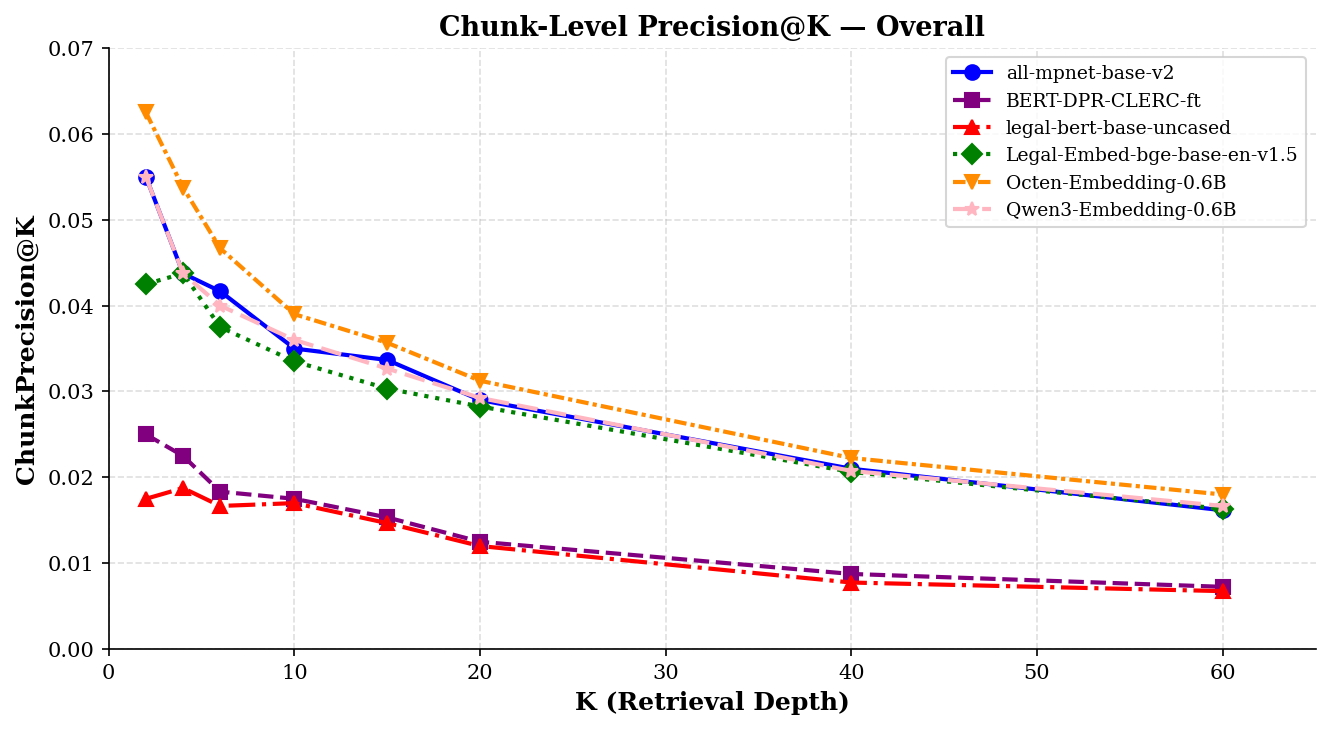

In [66]:
plot_one(
    runs,
    "chunk_precision_at_k",
    section="overall",
    title="Chunk-Level Precision@K — Overall",
    y_label="ChunkPrecision@K",
    ylim=(0.0, 0.07),
    save_to=f"{EVAL_ROOT}/{QUERY_TYPE[2]}/figures/overall_chunk_precision",
)

Saved → logs/eval/qwen3.5/figures/overall_char_precision.png


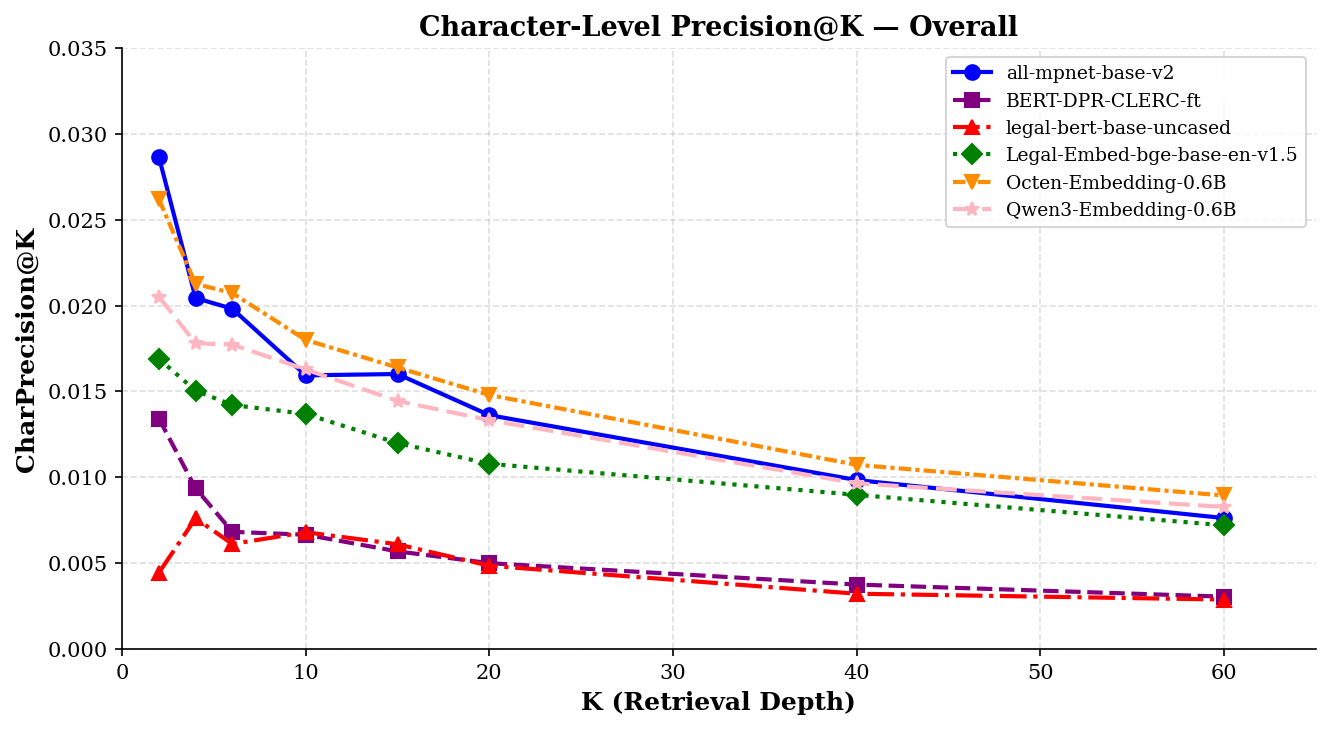

In [67]:
plot_one(
    runs,
    "char_precision_at_k",
    section="overall",
    title="Character-Level Precision@K — Overall",
    y_label="CharPrecision@K",
    ylim=(0.0, 0.035),
    save_to=f"{EVAL_ROOT}/{QUERY_TYPE[2]}/figures/overall_char_precision",
)

---
## Per-benchmark — contractnli

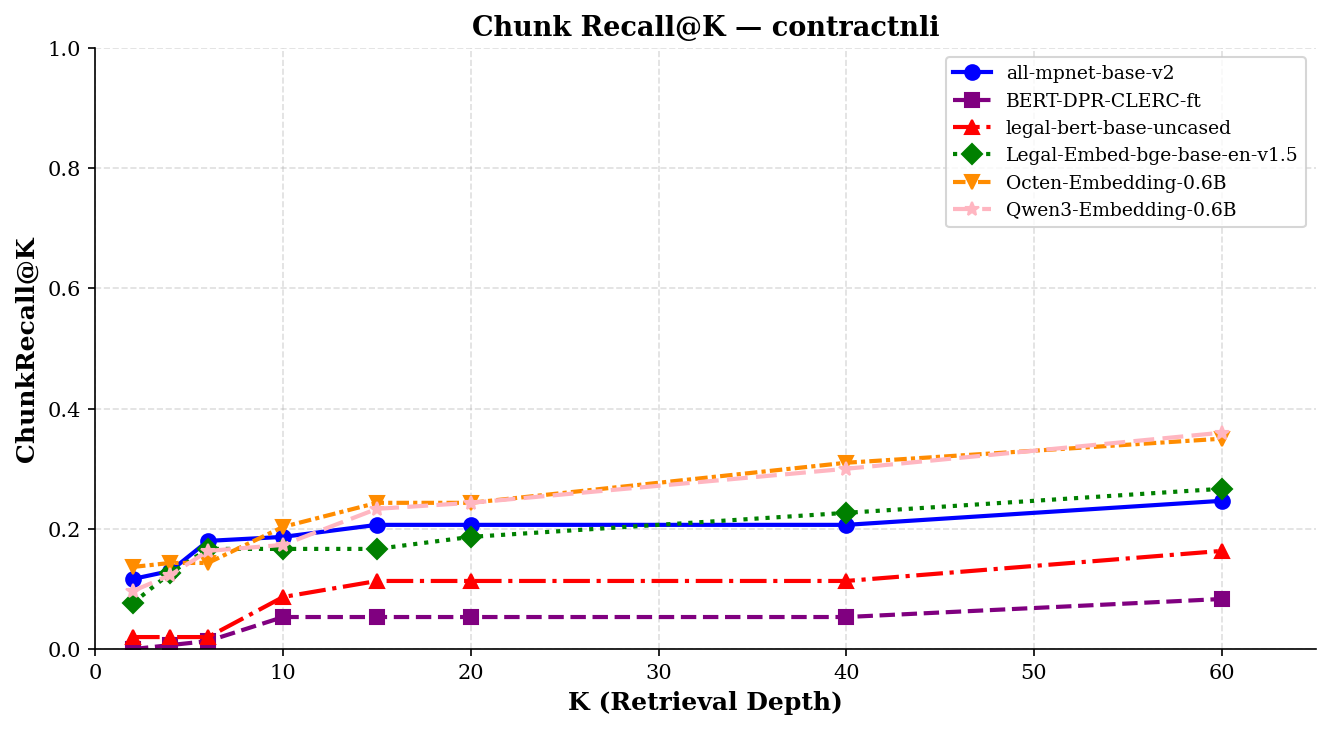

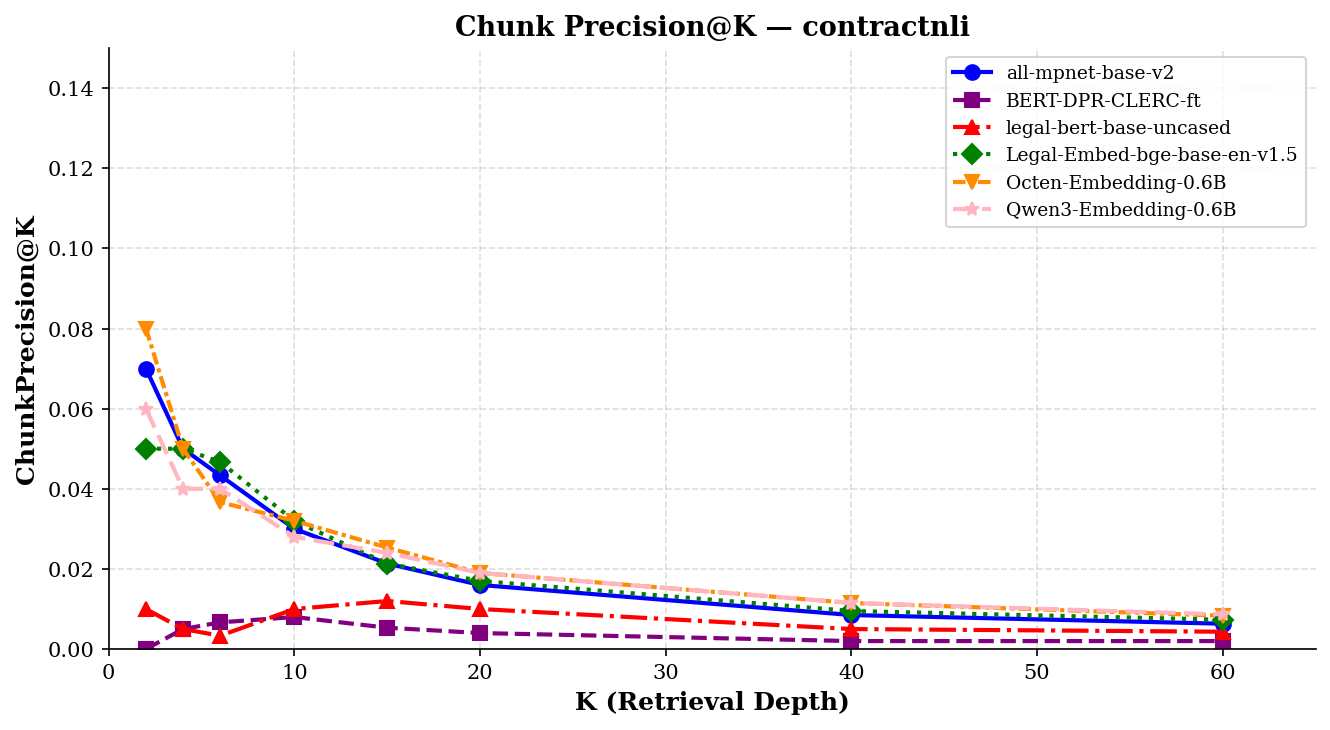

In [68]:
plot_one(runs,
        "chunk_recall_at_k",
        section="contractnli",
        title="Chunk Recall@K — contractnli",    
        y_label="ChunkRecall@K",    
        ylim=(0.0, 1.0))
plot_one(runs, "chunk_precision_at_k", 
         section="contractnli", 
         title="Chunk Precision@K — contractnli", 
         y_label="ChunkPrecision@K", 
         ylim=(0.0, 0.15))

---
## Per-benchmark — cuad

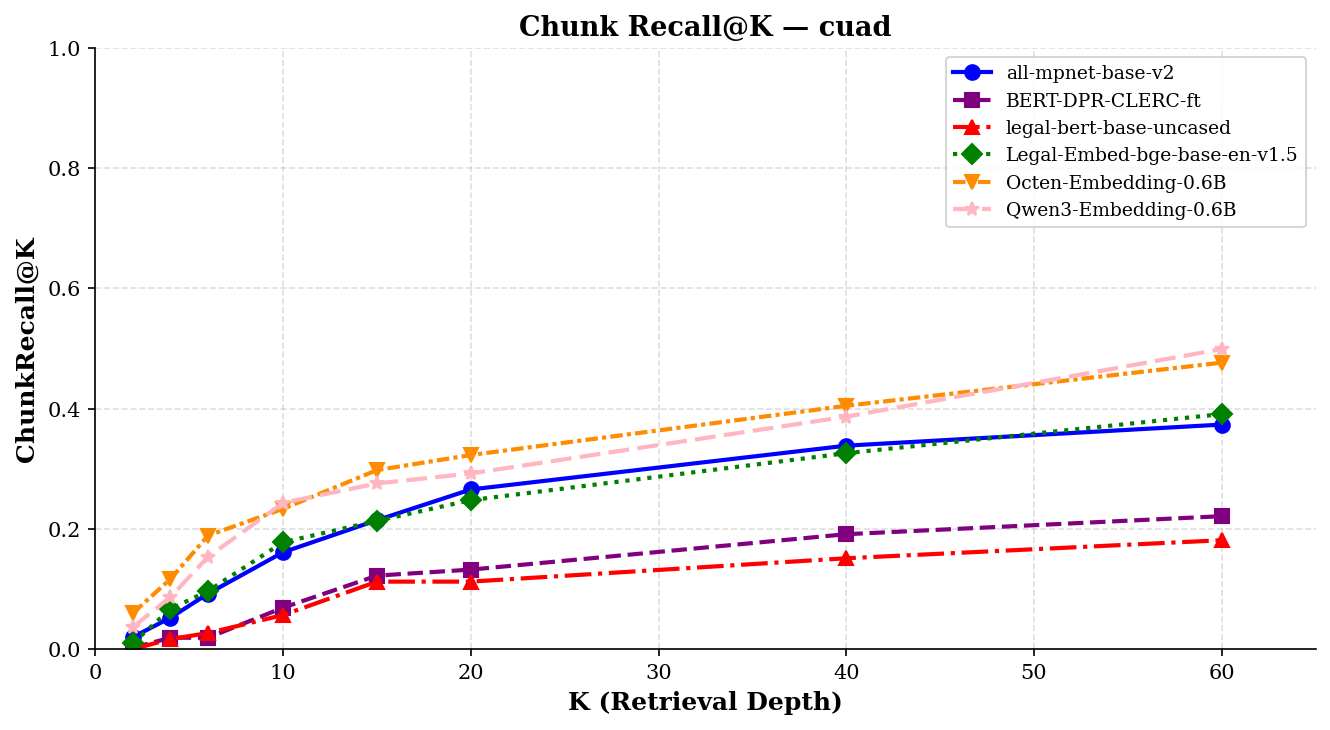

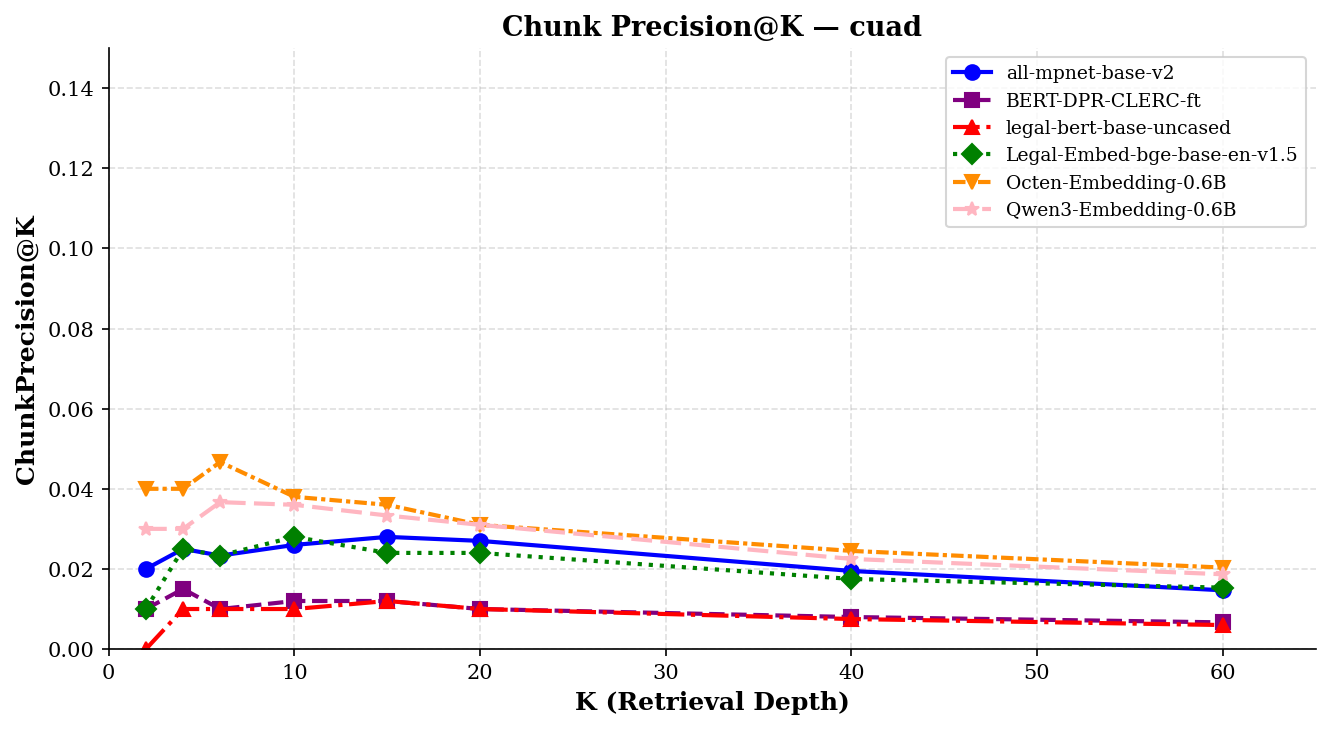

In [69]:
plot_one(runs, "chunk_recall_at_k",    
         section="cuad", 
         title="Chunk Recall@K — cuad",    
         y_label="ChunkRecall@K",    
         ylim=(0.0, 1.0))
plot_one(runs, "chunk_precision_at_k", 
         section="cuad", 
         title="Chunk Precision@K — cuad", 
         y_label="ChunkPrecision@K", 
         ylim=(0.0, 0.15))

---
## Per-benchmark — maud

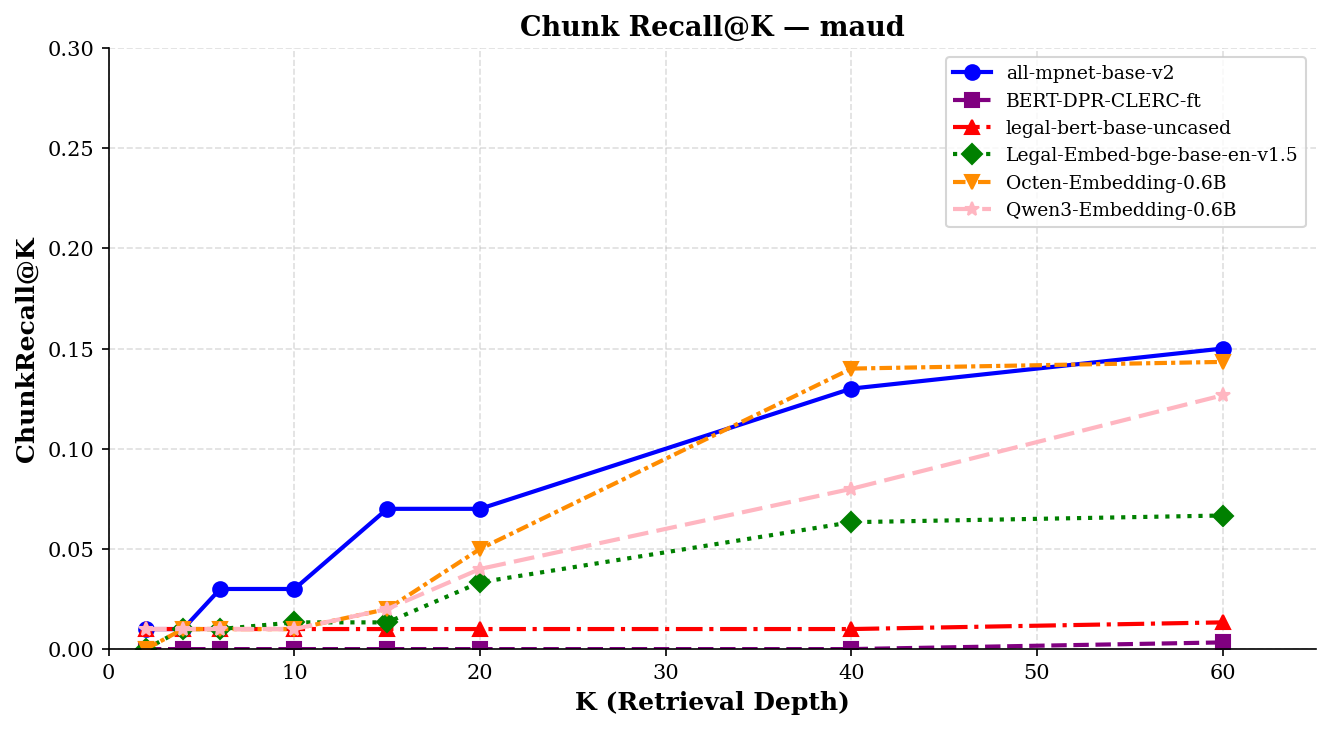

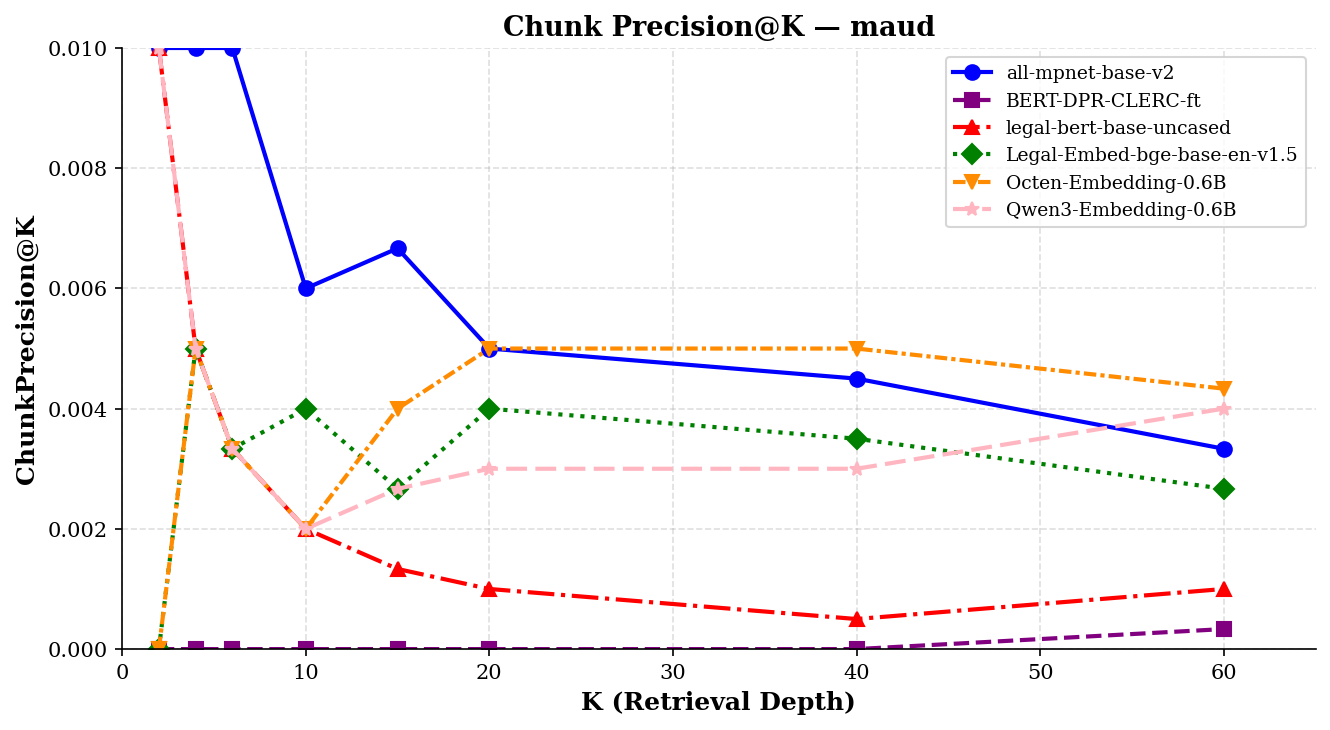

In [70]:
plot_one(runs, "chunk_recall_at_k",    
         section="maud", 
         title="Chunk Recall@K — maud",    
         y_label="ChunkRecall@K",    
         ylim=(0.0, 0.3))
plot_one(runs, "chunk_precision_at_k", 
         section="maud", 
         title="Chunk Precision@K — maud", 
         y_label="ChunkPrecision@K", 
         ylim=(0.0, 0.01))

---
## Per-benchmark — privacy_qa

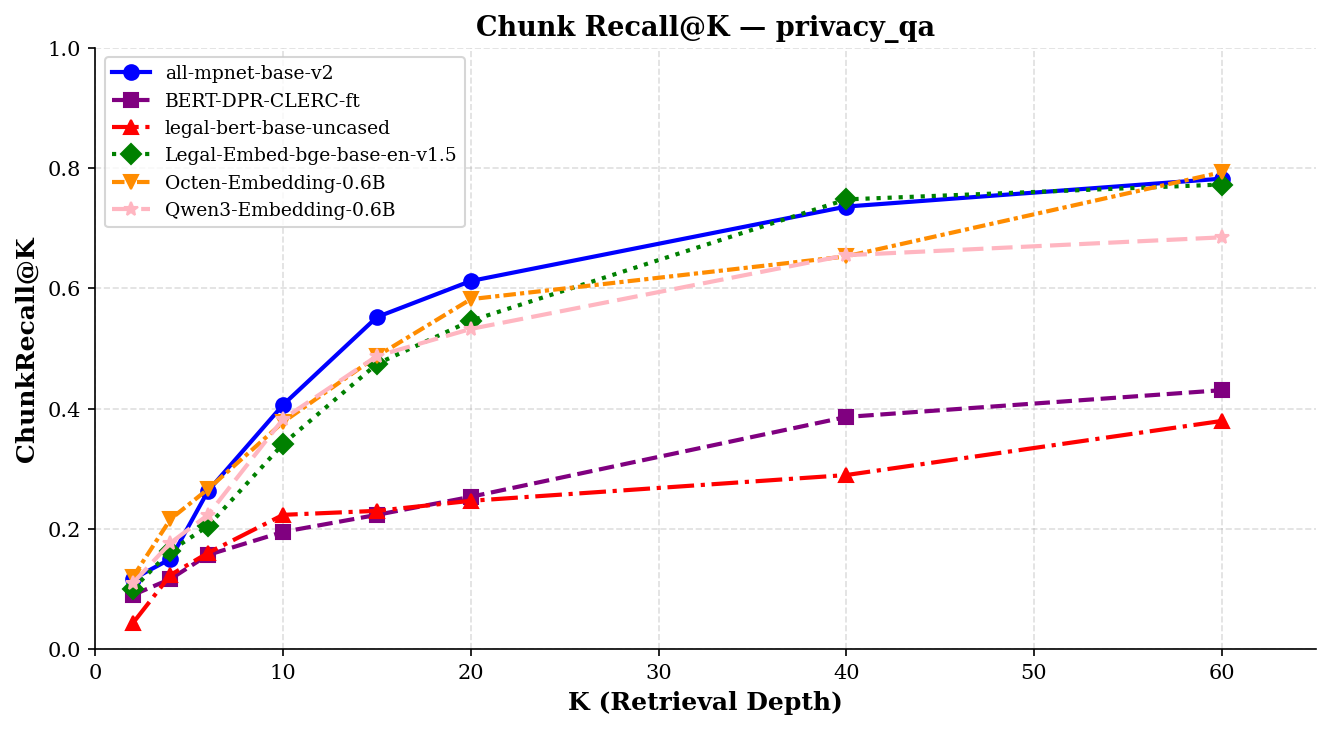

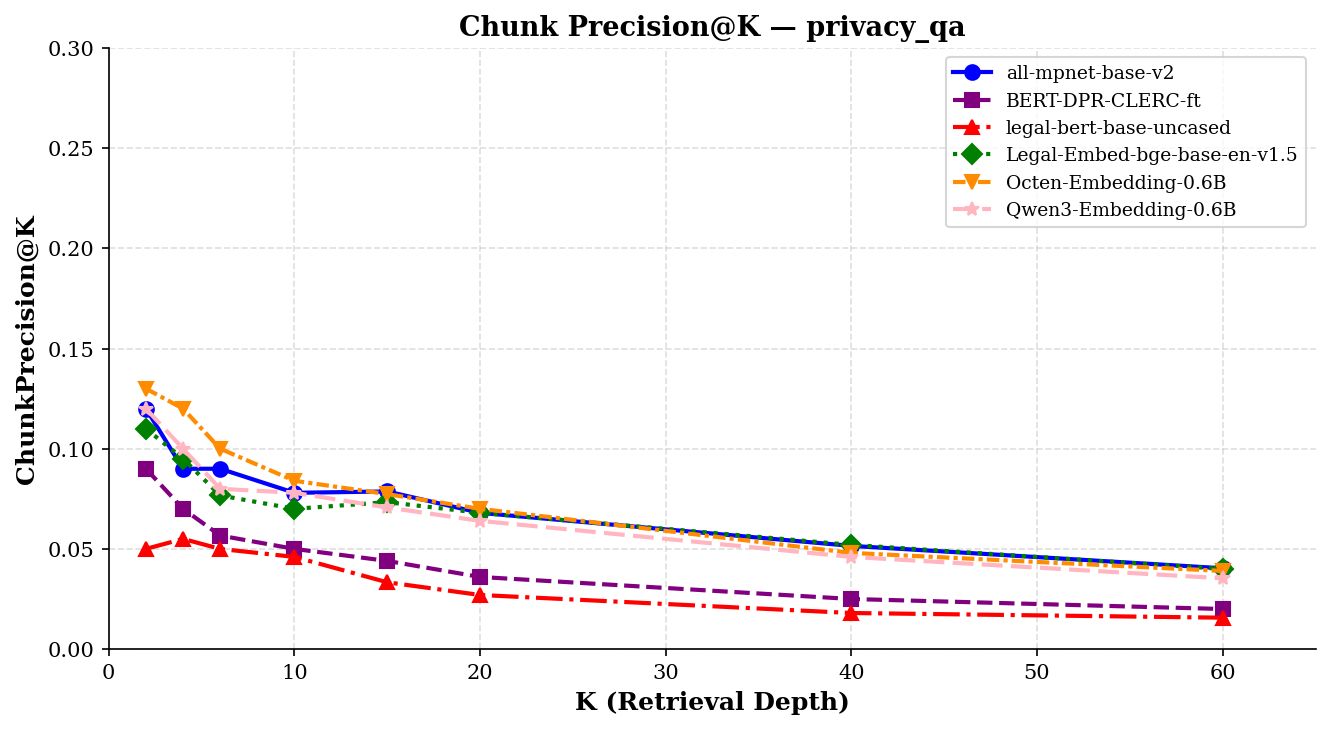

In [71]:
plot_one(runs, "chunk_recall_at_k",    
         section="privacy_qa", 
         title="Chunk Recall@K — privacy_qa",    
         y_label="ChunkRecall@K",    
         ylim=(0.0, 1.0))
plot_one(runs, "chunk_precision_at_k", 
         section="privacy_qa", 
         title="Chunk Precision@K — privacy_qa", 
         y_label="ChunkPrecision@K", 
         ylim=(0.0, 0.30))